In [5]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from google.colab import files

In [6]:
df = pd.read_csv('/content/lt_data.csv')

In [7]:
df.shape

(200, 26)

In [8]:
X = df.drop('label', axis=1).values
y = df['label'].values

In [9]:
X.shape

(200, 25)

In [10]:
y.shape

(200,)

In [11]:
split    = int( 0.8 * len(X) )

X_train  = X[:split]
X_test   = X[split:]
y_train  = y[:split]
y_test   = y[split:]

In [12]:
def activation_function(z):
    return np.where( z>=0, 1, 0  )

In [13]:
list_losses = []
list_epochs_loss = []

def fit(X_train, y_train):
    learning_rate = 0.01

    n_samples, n_features = X_train.shape

    weights = np.zeros( n_features )
    bias = 0

    for _ in range(1000):
        for idx, x_i in enumerate(X_train):

            linear_product = np.dot(x_i, weights) + bias    ## y = w*x + b
            y_pred  = activation_function(    linear_product    )

            loss =  y_pred   -  y_train[idx]
            list_losses.append( loss  )

            update = learning_rate * ( y_pred   -  y_train[idx] )

            weights = weights - update * x_i
            bias    = bias - update

        avg = sum(list_losses) / len( list_losses  )
        list_epochs_loss.append( avg  )

    return weights, bias

In [14]:
def predict(X_test, weights, bias):
    linear_product = np.dot(X_test, weights) + bias    ## y = w*x + b
    y_pred  = activation_function(    linear_product    )
    return y_pred

In [16]:
def accuracy(y_true, y_pred):
    accuracy = np.sum(   y_true == y_pred   ) / len(  y_true  )
    return accuracy

In [17]:
weights, bias = fit(X_train, y_train)

In [18]:
weights

array([-2.00000000e-02,  3.46944695e-18,  9.00000000e-02, -1.00000000e-02,
        1.00000000e-02,  3.00000000e-02,  4.00000000e-02,  2.00000000e-02,
        4.00000000e-02,  2.00000000e-02,  6.00000000e-02, -1.00000000e-02,
        4.00000000e-02,  1.00000000e-02,  3.00000000e-02,  1.00000000e-02,
        3.00000000e-02,  2.00000000e-02,  3.00000000e-02,  1.00000000e-02,
        3.46944695e-18,  3.00000000e-02,  3.00000000e-02,  2.00000000e-02,
        3.46944695e-18])

In [19]:
bias

np.float64(-0.08)

In [20]:
y_pred = predict(X_test, weights, bias)

In [21]:
y_pred

array([1, 1, 1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
       1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 0, 0, 1, 1, 1, 1, 1])

In [22]:
y_test

array([1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 1, 1, 1, 0, 0, 0, 0, 1, 1, 1,
       1, 0, 0, 0, 0, 1, 1, 1, 1, 1, 0, 0, 0, 1, 1, 1, 0, 1])

In [23]:
print(  accuracy(y_pred, y_test)   )

0.65


In [24]:
x_vals = np.arange( len(list_epochs_loss) )

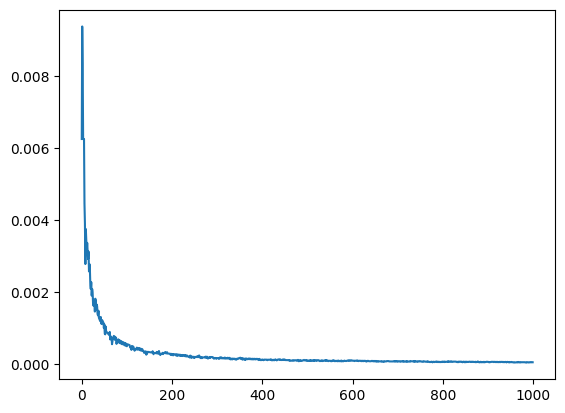

In [25]:
plt.plot(x_vals, list_epochs_loss)

In [26]:
weight_grid = weights.reshape( 5, 5 )

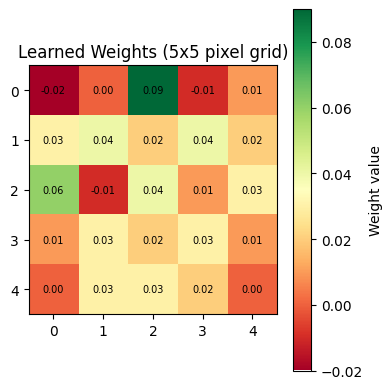

In [27]:
plt.figure(figsize=(4, 4))
plt.imshow(weight_grid, cmap='RdYlGn', interpolation='nearest')
plt.colorbar(label='Weight value')
plt.title('Learned Weights (5x5 pixel grid)')
plt.xticks(range(5))
plt.yticks(range(5))

for i in range(5):
    for j in range(5):
        plt.text(j, i, f'{weight_grid[i,j]:.2f}', ha='center', va='center', fontsize=7)

plt.tight_layout()
plt.show()

In [28]:
w_clean = [round(float(w), 6) for w in weights]
print( 'weights =', w_clean )
print( 'bias    =', round( float(bias), 6 ) )

weights = [-0.02, 0.0, 0.09, -0.01, 0.01, 0.03, 0.04, 0.02, 0.04, 0.02, 0.06, -0.01, 0.04, 0.01, 0.03, 0.01, 0.03, 0.02, 0.03, 0.01, 0.0, 0.03, 0.03, 0.02, 0.0]
bias    = -0.08
